In [1]:
from environment import Environment
from collections import defaultdict
import pandas as pd
import os
import matplotlib.pyplot as plt
import math
import random
import numpy as np

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

N = 200000
BATCH_SIZE = 10000

for warning in []:  # ['yellow', 'amber', 'red']
    print(warning)
    csv_path = f"warning/samples/{warning}_samples.csv"
    environment = Environment(use_historic=warning)
    header_written = False  # Always start fresh
    first_batch = True      # Track whether to overwrite or append

    batch = defaultdict(list)

    for i in range(N):
        # --------------- Sampling
        environment.sample_features()
        environment.update_derived()

        # --------------- Saving samples
        for key, value in environment.samples.features.items():
            if key not in ("season", "geometry"):
                batch[key].append(value)

        for key, value in environment.derived.items():
            batch[key].append(value)

        batch["impact"].append(environment.impact)

        # Flush to disk every BATCH_SIZE iterations
        if (i + 1) % BATCH_SIZE == 0:
            print(f"Batch {(i + 1) // BATCH_SIZE}")
            df = pd.DataFrame(batch)
            df.to_csv(csv_path, mode="w" if first_batch else "a", index=False, header=not header_written)
            header_written = True
            first_batch = False
            batch = defaultdict(list)

    # Write any remaining rows
    if batch:
        df = pd.DataFrame(batch)
        df.to_csv(csv_path, mode="w" if first_batch else "a", index=False, header=not header_written)

yellow
Batch 1
Batch 2
Batch 3
Batch 4
Batch 5
Batch 6
Batch 7
Batch 8
Batch 9
Batch 10
Batch 11
Batch 12
Batch 13
Batch 14
Batch 15
Batch 16
Batch 17
Batch 18
Batch 19
Batch 20


In [5]:
df = pd.read_csv("warning/samples/red_samples.csv")
duplicates = df.duplicated()
print(f"Duplicate rows: {duplicates.sum()}")

Duplicate rows: 0


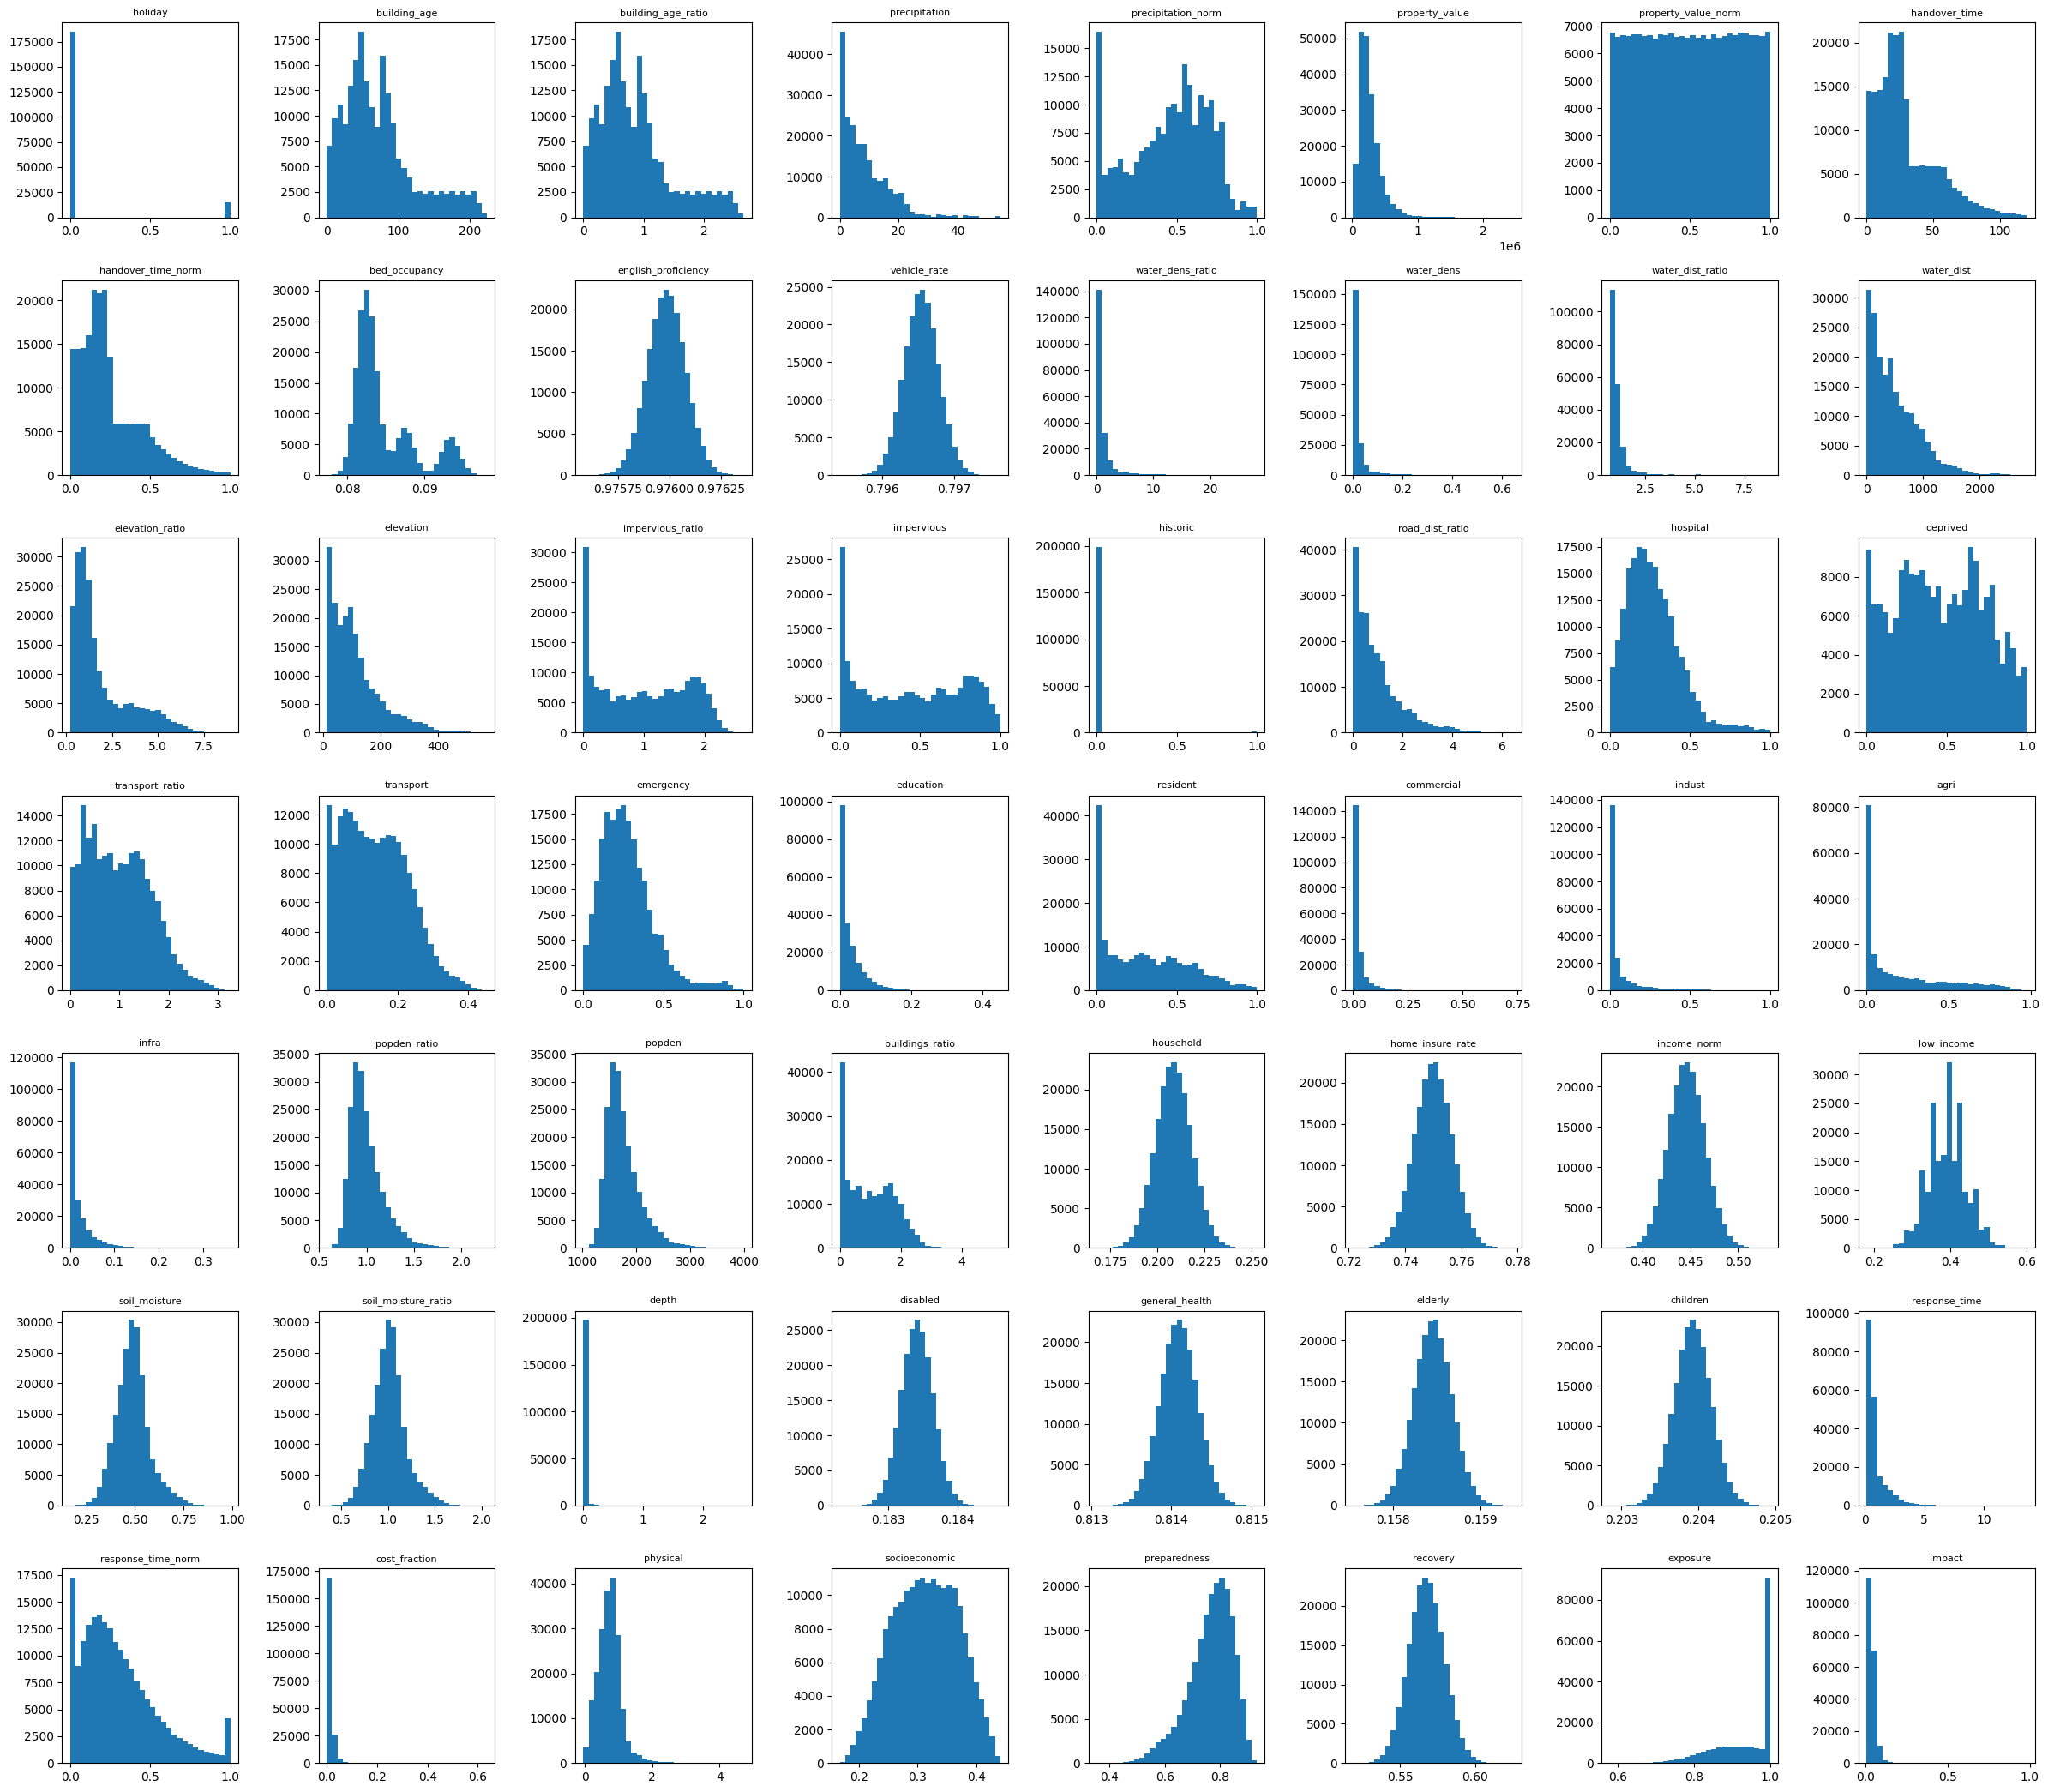

In [4]:
warning = "yellow"

df = pd.read_csv(f"warning/samples/{warning}_samples.csv")

n = len(df.columns)

ncols = math.ceil(math.sqrt(n))
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
axes = axes.flatten()

for ax, col in zip(axes, df.columns):
    ax.hist(df[col].dropna(), bins=30)
    ax.set_title(col, fontsize=8)

# hide unused axes
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

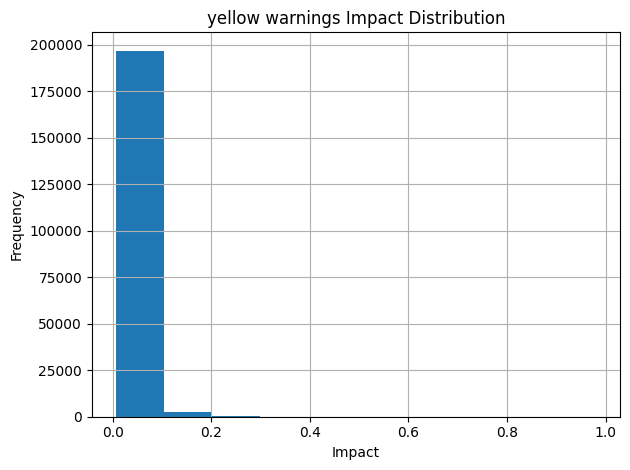

In [5]:
df['impact'].hist()
plt.title(f'{warning} warnings Impact Distribution')
plt.xlabel('Impact')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [6]:
print(df['impact'].describe())

count    200000.000000
mean          0.040800
std           0.024089
min           0.006768
25%           0.026542
50%           0.035871
75%           0.048918
max           0.980372
Name: impact, dtype: float64


In [7]:
# Count how many > 0.1
print((df['impact'] > 0.1).sum())
# Count how many > 0.980372


3595


In [ ]:
'''
19 years (2006-2025) -> 6935 days
  yellow       1474 rows
  amber         448 rows
  red            20 rows

1942 / 6935
aprox 29% warnings

200000 days
Yellow: 42509
Amber: 12920
Red: 577



Lines for 
x = warning_rows[i] * (6935/200000)
x = ... when total warning_rows = (1942/6935)*200000
'''

'\n150000 days\n19 years (2006-2025) -> 6935 days\n  yellow       1474 rows\n  amber         448 rows\n  red            20 rows\n\n1942 / 6935\naprox 29% warnings\n\n150000 days\nYellow: 31882\nAmber: 9670\nRed: 433\n\n\n'

In [27]:
import pandas as pd

# Get total historical flood warnings (excludes duplicate same day warnings (same day, different area))
total = 0
warning_rows = []
warnings = ['yellow', 'amber', 'red']
for warning in warnings:
    csv_path = f"warning/{warning}_warnings.csv"
    df = pd.read_csv(csv_path)
    rows = len(df)
    print(f"  {warning:<10} {rows:>6} rows")
    total += rows
    warning_rows.append(rows)
print(f"  {'TOTAL':<10} {total:>6} rows\n")

# Find impact thresholds using historical samples and random
no_warning_threshold = 0.0439
warnings.append('random')
for warning in warnings:
    print(f"-- {warning.upper()} --")
    csv_path = f"warning/samples/{warning}_samples.csv"
    df = pd.read_csv(csv_path)
    print(f"Count: {len(df)}")
    df = df.loc[df['impact'] > no_warning_threshold]
    for i in range(3):
        p_start = no_warning_threshold + (sum(warning_rows[:i])   / total) * (1 - no_warning_threshold)
        p_end   = no_warning_threshold + (sum(warning_rows[:i+1]) / total) * (1 - no_warning_threshold)
        q_start = df['impact'].quantile(p_start)
        q_end   = df['impact'].quantile(p_end)
        rows_in_range = int(len(df) * (p_end - p_start))
        print(f"  [{warnings[i]}] {p_start:.4%} - {p_end:.4%}  ->  impact: {q_start:.4f} - {q_end:.4f} ({rows_in_range} rows)")
    print()

  yellow       1474 rows
  amber         448 rows
  red            20 rows
  TOTAL        1942 rows

-- YELLOW --
Count: 200000
  [yellow] 4.3900% - 76.9591%  ->  impact: 0.0447 - 0.0701 (47831 rows)
  [amber] 76.9591% - 99.0153%  ->  impact: 0.0701 - 0.1726 (14537 rows)
  [red] 99.0153% - 100.0000%  ->  impact: 0.1726 - 0.9804 (648 rows)

-- AMBER --
Count: 200000
  [yellow] 4.3900% - 76.9591%  ->  impact: 0.0447 - 0.0712 (50089 rows)
  [amber] 76.9591% - 99.0153%  ->  impact: 0.0712 - 0.1812 (15223 rows)
  [red] 99.0153% - 100.0000%  ->  impact: 0.1812 - 0.9878 (679 rows)

-- RED --
Count: 200000
  [yellow] 4.3900% - 76.9591%  ->  impact: 0.0447 - 0.0715 (47197 rows)
  [amber] 76.9591% - 99.0153%  ->  impact: 0.0715 - 0.1829 (14344 rows)
  [red] 99.0153% - 100.0000%  ->  impact: 0.1829 - 1.0130 (640 rows)

-- RANDOM --
Count: 200000
  [yellow] 4.3900% - 76.9591%  ->  impact: 0.0447 - 0.0673 (42606 rows)
  [amber] 76.9591% - 99.0153%  ->  impact: 0.0673 - 0.1657 (12949 rows)
  [red] 9

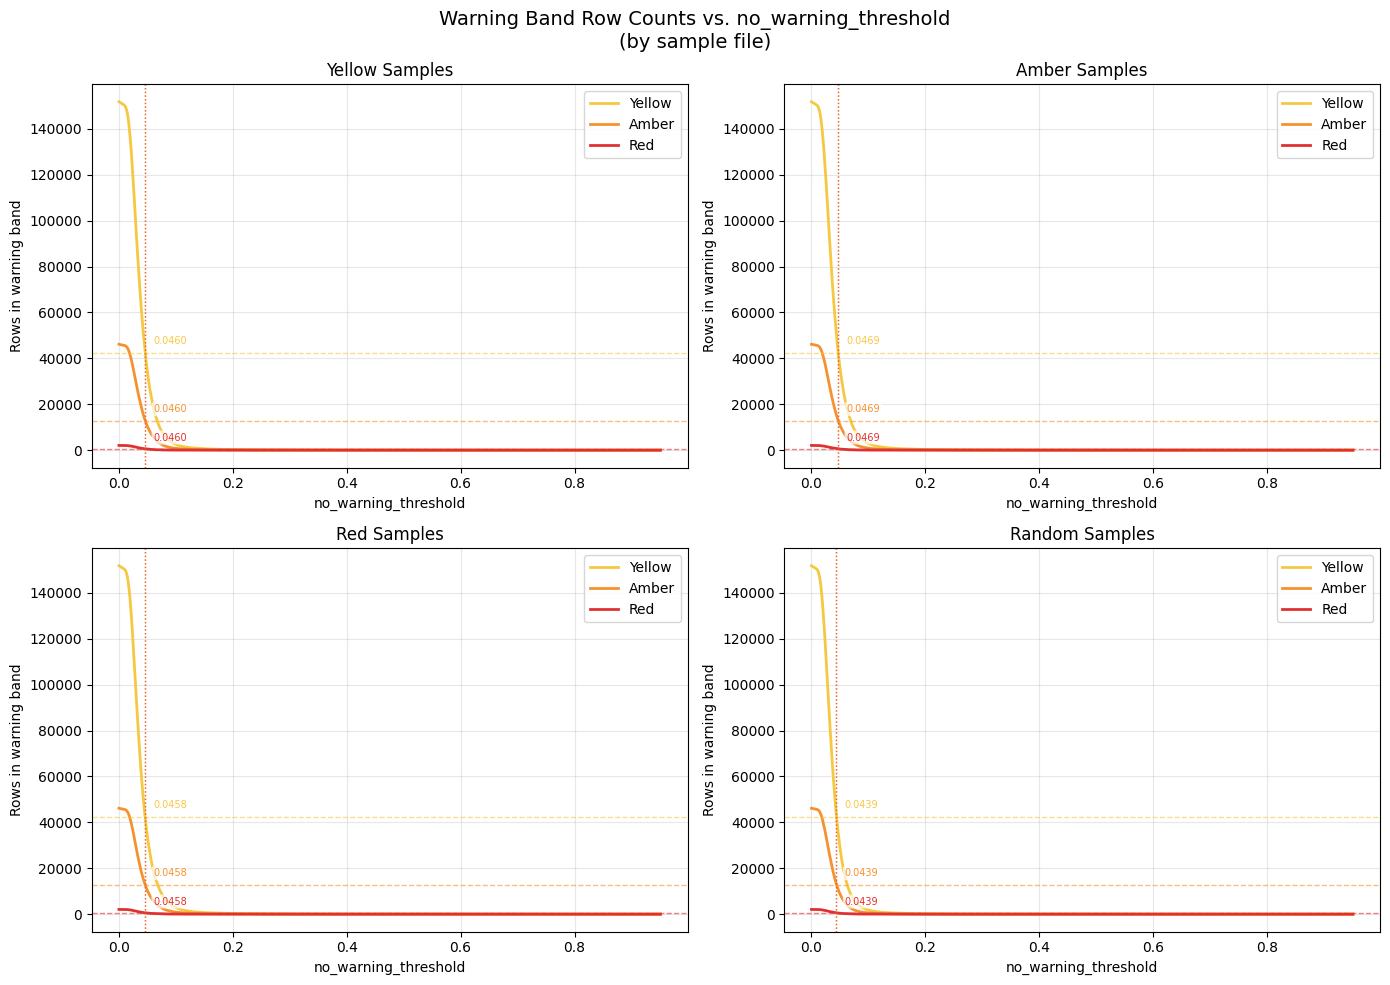

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load warning row counts
warnings = ['yellow', 'amber', 'red']
warning_rows = []
for warning in warnings:
    df = pd.read_csv(f"warning/{warning}_warnings.csv")
    warning_rows.append(len(df))
total = sum(warning_rows)

# Load all sample dataframes upfront
sample_dfs = {}
for w in ['yellow', 'amber', 'red', 'random']:
    sample_dfs[w] = pd.read_csv(f"warning/samples/{w}_samples.csv")

# Sweep no_warning_threshold
thresholds = np.arange(0, 0.951, 0.0001)
colors = {'yellow': '#f5c842', 'amber': '#f5922f', 'red': '#e03131'}

# Threshold lines for yellow, amber, red counts
threshold_lines = {'yellow': 42509, 'amber': 12920, 'red': 577}

sample_names = ['yellow', 'amber', 'red', 'random']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, sample_name in zip(axes, sample_names):
    df_sample = sample_dfs[sample_name]
    results = {w: [] for w in warnings}

    for t in thresholds:
        df_filtered = df_sample.loc[df_sample['impact'] > t]
        for i, w in enumerate(warnings):
            p_start = t + (sum(warning_rows[:i])   / total) * (1 - t)
            p_end   = t + (sum(warning_rows[:i+1]) / total) * (1 - t)
            rows_in_range = int(len(df_filtered) * (p_end - p_start))
            results[w].append(rows_in_range)

    for w in warnings:
        ax.plot(thresholds, results[w], label=w.capitalize(), color=colors[w], linewidth=2)

    # Add horizontal lines and annotate where each warning curve crosses it
    for w, target in threshold_lines.items():
        ax.axhline(y=target, color=colors[w], linewidth=1, linestyle='--', alpha=0.6)

        # Find where the curve crosses the target (first crossing)
        curve = np.array(results[w])
        diffs = curve - target
        cross_idx = np.where(np.diff(np.sign(diffs)))[0]

        if len(cross_idx) > 0:
            idx = cross_idx[0]
            # Interpolate for a more precise x value
            x0, x1 = thresholds[idx], thresholds[idx + 1]
            y0, y1 = curve[idx], curve[idx + 1]
            x_cross = x0 + (target - y0) * (x1 - x0) / (y1 - y0)

            ax.axvline(x=x_cross, color=colors[w], linewidth=1, linestyle=':', alpha=0.6)
            ax.annotate(
                f'{x_cross:.4f}',
                xy=(x_cross, target),
                xytext=(6, 6),
                textcoords='offset points',
                fontsize=7,
                color=colors[w],
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none')
            )

    ax.set_title(f'{sample_name.capitalize()} Samples')
    ax.set_xlabel('no_warning_threshold')
    ax.set_ylabel('Rows in warning band')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Warning Band Row Counts vs. no_warning_threshold\n(by sample file)', fontsize=14)
plt.tight_layout()
plt.show()